# Transcription Factor Project - Replogle et al. (2022) K562 dataset QC
**Robin Anwyl, UCSD Subramaniam Lab**

**Goal:** Analyze the hiPSC Perturb-seq dataset from the Mali lab (Nourreddine et al 2023 preprint) to investigate the effects of transcription factor knockdowns (TF KDs). Compare to the Replogle et al. (2022) K562 dataset to compare hiPSCs to chronic myeloid leukemia cells.

**Guiding Questions:** What do TF KD effects reveal about:
* … the transcription regulatory network of hiPSCs, and TF crosstalk?
* … cell lineage?
* … how TFs influence chromatin remodeling?

***

# Import statements

In [1]:
import sys
import os
repo_root = "/home/ranwyl/KOLF2.1J_Perturbation_Cell_Atlas/"
if repo_root not in sys.path:
    sys.path.insert(0, "/home/ranwyl/KOLF2.1J_Perturbation_Cell_Atlas/")

import psp
import gc
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'

In [4]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import seaborn as sns

# Download raw dataset from Figshare API

In [2]:
import requests
import json
import os
import sys

BASE_URL = "https://api.figshare.com/v2"
ARTICLE_ID = 20029387
FILE_ID = 35775507
OUTFILE = "/home/ranwyl/data_tf_project/K562_gwps_raw_singlecell_01.h5ad"

CHUNK_SIZE = 1024 * 1024  # 1 MB


# Step 1: get file metadata
files_url = f"{BASE_URL}/articles/{ARTICLE_ID}/files"
r = requests.get(files_url)
r.raise_for_status()

files = r.json()

file_meta = None
for f in files:
    if f["id"] == FILE_ID:
        file_meta = f
        break

if file_meta is None:
    raise RuntimeError("File not found")

print("File metadata:")
print(json.dumps(file_meta, indent=2))

download_url = file_meta["download_url"]
total_size = file_meta["size"]

print("\nDownload URL:", download_url)


# Step 2: determine resume position
resume_pos = 0
if os.path.exists(OUTFILE):
    resume_pos = os.path.getsize(OUTFILE)

headers = {}

mode = "wb"

if resume_pos > 0:
    headers["Range"] = f"bytes={resume_pos}-"
    mode = "ab"
    print(f"\nResuming download at {resume_pos / 1e9:.2f} GB")

print("\nAttempting download...")

with requests.get(download_url, headers=headers, stream=True) as r:
    print("HTTP status:", r.status_code)

    with open(OUTFILE, mode) as f:
        downloaded = resume_pos

        for chunk in r.iter_content(chunk_size=CHUNK_SIZE):
            if chunk:
                f.write(chunk)
                downloaded += len(chunk)

                percent = downloaded / total_size * 100
                gb_done = downloaded / 1e9
                gb_total = total_size / 1e9

                sys.stdout.write(
                    f"\rDownloaded {gb_done:.2f} / {gb_total:.2f} GB ({percent:.2f}%)"
                )
                sys.stdout.flush()

print("\nDownload complete.")

File metadata:
{
  "id": 35775507,
  "name": "K562_gwps_raw_singlecell_01.h5ad",
  "size": 65830941948,
  "is_link_only": false,
  "download_url": "https://ndownloader.figshare.com/files/35775507",
  "supplied_md5": "887e3e6a8c8df6eadf7a3030a53c9546",
  "computed_md5": "",
  "mimetype": "undefined"
}

Download URL: https://ndownloader.figshare.com/files/35775507

Resuming download at 0.22 GB

Attempting download...
HTTP status: 206
Downloaded 65.83 / 65.83 GB (100.00%)
Download complete.


# Inspect dataset

In [3]:
filepath = "/home/ranwyl/data_tf_project/K562_gwps_raw_singlecell_01.h5ad"
adata_k562_backed = sc.read_h5ad(filepath, backed='r')
adata_k562_backed

AnnData object with n_obs × n_vars = 1989578 × 8248 backed at '/home/ranwyl/data_tf_project/K562_gwps_raw_singlecell_01.h5ad'
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano'

Inspect obs and var

In [5]:
adata_k562_backed.obs.head(3)

,gem_group,gene,gene_id,transcript,gene_transcript,sgID_AB,mitopercent,UMI_count,z_gemgroup_UMI,core_scale_factor,core_adjusted_UMI_count
cell_barcode,,,,,,,,,,,
AAACCCAAGAAACCAT-157,157,CTSC,ENSG00000109861,P1P2,1946_CTSC_P1P2_ENSG00000109861,CTSC_-_88070848.23-P1P2|CTSC_-_88070918.23-P1P2,0.088177,14709.0,0.470687,1.051176,13992.900391
AAACCCAAGAAACCAT-207,207,CWC25,ENSG00000273559,P1P2,1973_CWC25_P1P2_ENSG00000273559,CWC25_+_36981555.23-P1P2|CWC25_+_36981567.23-P1P2,0.114342,16162.0,0.824790,1.074744,15038.004883
AAACCCAAGAAACCAT-29,29,PDE4DIP,ENSG00000178104,ENST00000313431.9,6168_PDE4DIP_ENST00000313431.9_ENSG00000178104,PDE4DIP_+_144932474.23-ENST00000313431.9|PDE4D...,0.107157,33297.0,2.627126,1.472444,22613.423828


In [6]:
adata_k562_backed.var.head()

,gene_name,chr,start,end,class,strand,length,in_matrix,mean,std,cv,fano
gene_id,,,,,,,,,,,,
ENSG00000237491,LINC01409,chr1,778747,810065,gene_version10,+,31318,True,0.116626,0.349971,3.000803,1.050194
ENSG00000228794,LINC01128,chr1,825138,868202,gene_version9,+,43064,True,0.182850,0.437274,2.391434,1.045713
ENSG00000188976,NOC2L,chr1,944203,959309,gene_version11,-,15106,True,1.415674,1.397208,0.986957,1.378984
ENSG00000187961,KLHL17,chr1,960584,965719,gene_version14,+,5135,True,0.105599,0.330678,3.131439,1.035497
ENSG00000188290,HES4,chr1,998962,1000172,gene_version10,-,1210,True,0.242700,0.550596,2.268630,1.249098


Name of NTC condition

In [22]:
print("non-targeting" in adata_k562_backed.obs.gene.unique())

True


In [23]:
adata_k562_ntc = adata_k562_backed[adata_k562_backed.obs.gene == "non-targeting"]
adata_k562_ntc

View of AnnData object with n_obs × n_vars = 75328 × 8248 backed at '/home/ranwyl/data_tf_project/K562_gwps_raw_singlecell_01.h5ad'
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano'

In [25]:
adata_k562_ntc.obs.head(3)

,gem_group,gene,gene_id,transcript,gene_transcript,sgID_AB,mitopercent,UMI_count,z_gemgroup_UMI,core_scale_factor,core_adjusted_UMI_count
cell_barcode,,,,,,,,,,,
AAACCCAAGAGTGAAG-129,129,non-targeting,non-targeting,non-targeting,11147_non-targeting_non-targeting_non-targeting,non-targeting_02596|non-targeting_01746,0.142966,6589.0,-0.841324,0.745740,8835.518555
AAACCCAAGATACATG-238,238,non-targeting,non-targeting,non-targeting,11000_non-targeting_non-targeting_non-targeting,non-targeting_01628|non-targeting_03433,0.107690,10976.0,-0.351153,1.055636,10397.521484
AAACCCAAGCACTCCG-164,164,non-targeting,non-targeting,non-targeting,11119_non-targeting_non-targeting_non-targeting,non-targeting_02458|non-targeting_03087,0.096043,5560.0,0.415484,0.409556,13575.676758


Check number of GEM groups (batches) for full dataset and for NTC cells

In [4]:
adata_k562_backed.obs.gem_group.nunique()

267

In [30]:
adata_k562_ntc.obs.gem_group.nunique()

267

Each GEM group has perturbed and NTC cells.

Count number of unique NTC gRNAs - there should be either 514 ("core") or 585 (total)

In [37]:
all_ntc_AB_gRNAs = adata_k562_ntc.obs.sgID_AB.unique().tolist()
print(len(all_ntc_AB_gRNAs))
print(all_ntc_AB_gRNAs[:3])

514
['non-targeting_02596|non-targeting_01746', 'non-targeting_01628|non-targeting_03433', 'non-targeting_02458|non-targeting_03087']


Since there are 514 NTC gRNAs, the dataset NTC gRNAs have already been filtered to NTC gRNAs with a core phenotype.

Number of perturbations, perturbed cells, control cells

In [27]:
k562_gene_kds = set(adata_k562_backed[
    adata_k562_backed.obs.gene != "non-targeting"].obs.gene.unique())
k562_gene_kds_ensembl = set(adata_k562_backed[
    adata_k562_backed.obs.gene != "non_targeting"].obs.gene_id.unique())
print(f"K562 dataset has {len(k562_gene_kds)} unique gene KDs")

K562 dataset has 9866 unique gene KDs


In [28]:
print(f"K562 dataset has {adata_k562_backed[adata_k562_backed.obs.gene != 'non-targeting'].shape[0]} "
      f"perturbed cells and "
      f"{adata_k562_backed[adata_k562_backed.obs.gene == 'non-targeting'].shape[0]} NTC cells")

K562 dataset has 1914250 perturbed cells and 75328 NTC cells


How many perturbations are known human TFs from Lambert et al. (2018)

In [15]:
# List of 1639 TFs from Lambert et al (2018)
tf_filepath = "/home/ranwyl/data_tf_project/input_files/Lambert_2018_TFs.csv"
tf_csv = pd.read_csv(tf_filepath)
lambert_tfs = set(tf_csv[tf_csv["Is TF?"] == "Yes"].iloc[:,1].tolist())
print(f"{len(lambert_tfs)} human TFs in Lambert et al. (2018)")

1639 human TFs in Lambert et al. (2018)


In [10]:
tf_csv.head(3)

,Gene Information,Unnamed: 1,Unnamed: 2,Is TF?,Final Assesment,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Notes from re-reviewed genes,...,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36
0,ID,Name,DBD,NaN,TF assessment,Binding mode,Motif status,Notes,Comments,Committee notes,...,CisBP considers it as a TF?,TFclass considers it as a TF?,TF-CAT classification,Is a GO TF,PDB,NaN,NaN,NaN,NaN,NaN
1,ENSG00000137203,TFAP2A,AP-2,Yes,Known motif,1 Monomer or homomultimer,High-throughput in vitro,NaN,NaN,NaN,...,Yes,Yes,TF Gene_DNA-Binding: sequence-specific_DNA Bin...,Yes,NaN,NaN,NaN,NaN,NaN,NaN
2,ENSG00000008196,TFAP2B,AP-2,Yes,Known motif,1 Monomer or homomultimer,High-throughput in vitro,NaN,NaN,NaN,...,Yes,Yes,TF Gene_DNA-Binding: sequence-specific_DNA Bin...,Yes,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
k562_tf_kds = k562_gene_kds & lambert_tfs
print(f"K562 dataset has {len(k562_tf_kds)} TF KDs")

K562 dataset has 1595 TF KDs


In [29]:
adata_k562_tf_kd_ntc = adata_k562_backed[
    (adata_k562_backed.obs.gene == "non-targeting") | 
    (adata_k562_backed.obs.gene.isin(k562_tf_kds))]
adata_k562_tf_kd_ntc

View of AnnData object with n_obs × n_vars = 385858 × 8248 backed at '/home/ranwyl/data_tf_project/K562_gwps_raw_singlecell_01.h5ad'
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano'

Overlap between TF KDs in hiPSC dataset & K562 dataset

In [11]:
filepath = "/home/ranwyl/data_tf_project/KOLF_Pan_Genome_Alpha_CPMnorm_KD_ETest_Gene_gRNA_Filtered.h5ad"
adata_ipsc_backed = sc.read_h5ad(filepath, backed='r')
adata_ipsc_backed

AnnData object with n_obs × n_vars = 54766 × 16115 backed at '/home/ranwyl/data_tf_project/KOLF_Pan_Genome_Alpha_CPMnorm_KD_ETest_Gene_gRNA_Filtered.h5ad'
    obs: 'gRNA', 'n_gRNA', 'n_gRNA_UMIs', 'gene_target', 'celltype', 'perturbation_type', 'n_UMI_counts', 'n_genes', 'perturbed', 'channel', 'perturbation', 'gene_target_ensembl_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'gene_target_expression (CPM)', 'NTC_target_gene_expression (CPM)', 'target_knockdown', 'perturbation_edist', 'perturbation_pvalue', 'perturbation_significant'
    var: 'gene_ids', 'feature_types', 'n_UMI_counts', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'lo

In [34]:
adata_ipsc_backed.obs.head(3)

,gRNA,n_gRNA,n_gRNA_UMIs,gene_target,celltype,perturbation_type,n_UMI_counts,n_genes,perturbed,channel,...,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,outlier,gene_target_expression (CPM),NTC_target_gene_expression (CPM),target_knockdown,perturbation_edist,perturbation_pvalue,perturbation_significant
AAACGAACAAAGCGTG-1,Non-Targeting_186,1,10,NTC,KRAB-ZIM3-dCas9 KOLF2.1J hiPSC,CRISPRi,8525.0,3843,False,ALPHA-Chip-1-Channel-1,...,0.0,0.000000,0.000000,False,0.0,0.00000,0.0,0.000000,1.0000,False
AAACGAAGTGGACTAG-1,ZNF14_1,1,44,ZNF14,KRAB-ZIM3-dCas9 KOLF2.1J hiPSC,CRISPRi,4595.0,2571,True,ALPHA-Chip-1-Channel-1,...,0.0,0.000000,0.000000,False,0.0,7.92788,1.0,7.399397,0.0167,True
AAACGCTTCTCTTGCG-1,Non-Targeting_567,1,18,NTC,KRAB-ZIM3-dCas9 KOLF2.1J hiPSC,CRISPRi,3528.0,2129,False,ALPHA-Chip-1-Channel-1,...,1.0,0.693147,0.028345,False,0.0,0.00000,0.0,0.000000,1.0000,False


In [35]:
adata_ipsc_backed.var.head(3)

,gene_ids,feature_types,n_UMI_counts,n_cells,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
ENSG00000241860,ENSG00000241860,Gene Expression,230486.0,223092,False,False,False,97734,0.036800,0.036139,96.421320,100502.0,11.517942
ENSG00000290385,ENSG00000290385,Gene Expression,171820.0,167188,False,False,False,71421,0.026741,0.026390,97.384811,73030.0,11.198639
ENSG00000291215,ENSG00000291215,Gene Expression,222677.0,215587,False,False,False,90977,0.034163,0.033593,96.668738,93300.0,11.443586


In [12]:
ipsc_tf_kds = set(adata_ipsc_backed[adata_ipsc_backed.obs.perturbed == "True"].obs.gene_target.unique())
print(f"hiPSC dataset has {len(ipsc_tf_kds)} TF KDs")

hiPSC dataset has 350 TF KDs


In [25]:
shared_tf_kds = k562_tf_kds & ipsc_tf_kds
print(f"Intersection of {len(k562_tf_kds)} K562 TF KDs "
      f"& {len(ipsc_tf_kds)} hiPSC TF KDs = {len(shared_tf_kds)} TF KDs")

Intersection of 1595 K562 TF KDs & 350 hiPSC TF KDs = 345 TF KDs


In [31]:
k562_var_genes = set(adata_k562_backed.var_names)
ipsc_var_genes = set(adata_ipsc_backed.var.gene_ids.unique())
shared_var_genes = k562_var_genes & ipsc_var_genes
print(f"Intersection of {len(k562_var_genes)} K562 genes & "
      f"{len(ipsc_var_genes)} hiPSC genes (var) = {len(shared_var_genes)} genes")

Intersection of 8248 K562 genes & 16115 hiPSC genes (var) = 7996 genes


# Basic QC

In [3]:
filepath = "/home/ranwyl/data_tf_project/K562_gwps_raw_singlecell_01.h5ad"
adata_k562 = psp.utils.read_anndata(filepath)
adata_k562

AnnData object with n_obs × n_vars = 1989578 × 8248
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano'

In [4]:
adata_k562.obs.head(2)

,gem_group,gene,gene_id,transcript,gene_transcript,sgID_AB,mitopercent,UMI_count,z_gemgroup_UMI,core_scale_factor,core_adjusted_UMI_count
cell_barcode,,,,,,,,,,,
AAACCCAAGAAACCAT-157,157,CTSC,ENSG00000109861,P1P2,1946_CTSC_P1P2_ENSG00000109861,CTSC_-_88070848.23-P1P2|CTSC_-_88070918.23-P1P2,0.088177,14709.0,0.470687,1.051176,13992.900391
AAACCCAAGAAACCAT-207,207,CWC25,ENSG00000273559,P1P2,1973_CWC25_P1P2_ENSG00000273559,CWC25_+_36981555.23-P1P2|CWC25_+_36981567.23-P1P2,0.114342,16162.0,0.824790,1.074744,15038.004883


In [5]:
adata_k562.var.head(2)

,gene_name,chr,start,end,class,strand,length,in_matrix,mean,std,cv,fano
gene_id,,,,,,,,,,,,
ENSG00000237491,LINC01409,chr1,778747,810065,gene_version10,+,31318,True,0.116626,0.349971,3.000803,1.050194
ENSG00000228794,LINC01128,chr1,825138,868202,gene_version9,+,43064,True,0.182850,0.437274,2.391434,1.045713


Remove duplicate genes

In [6]:
duplicate_var_gene_names = adata_k562.var.gene_name.duplicated()
duplicate_gene_names = adata_k562.var.gene_name[duplicate_var_gene_names].tolist()
print(duplicate_gene_names)

['TBCE', 'HSPA14']


In [7]:
adata_k562[:, adata_k562.var.gene_name.isin(duplicate_gene_names)].var

,gene_name,chr,start,end,class,strand,length,in_matrix,mean,std,cv,fano
gene_id,,,,,,,,,,,,
ENSG00000285053,TBCE,chr1,235328570,235448952,gene_version1,+,120382,True,0.121394,0.356806,2.939253,1.048745
ENSG00000284770,TBCE,chr1,235367360,235452443,gene_version2,+,85083,True,0.113635,0.343425,3.022184,1.037893
ENSG00000284024,HSPA14,chr10,14838160,14847018,gene_version2,+,8858,True,0.265679,0.533176,2.006840,1.069999
ENSG00000187522,HSPA14,chr10,14838306,14871741,gene_version16,+,33435,True,0.509796,0.768371,1.507215,1.158101


Manual search (GeneCards)
-  TBCE: Ensembl ID ENSG00000284770 encodes Tubulin Folding Cofactor E (gene symbol TBCE, Entrez ID 6905), while Ensembl ID ENSG00000285053 encodes "Novel Protein, GGPS1-TBCE Readthrough" (no Entrez ID)
-  HSPA14: Ensembl ID ENSG00000187522 encodes Heat Shock Protein Family A Member 14 (gene symbol HSPA14, Entrez ID 51182), while Ensembl ID ENSG00000284024 encodes Myb/SANT DNA Binding Domain Containing 7 (gene symbol MSANTD7)

Remove genes ENSG00000285053 and ENSG00000284024 from var

In [8]:
genes_to_remove = ["ENSG00000285053", "ENSG00000284024"]
adata_k562 = adata_k562[:, ~adata_k562.var_names.isin(genes_to_remove)].copy()
adata_k562

AnnData object with n_obs × n_vars = 1989578 × 8246
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano'

In [9]:
adata_k562[:, adata_k562.var.gene_name.isin(duplicate_gene_names)].var

,gene_name,chr,start,end,class,strand,length,in_matrix,mean,std,cv,fano
gene_id,,,,,,,,,,,,
ENSG00000284770,TBCE,chr1,235367360,235452443,gene_version2,+,85083,True,0.113635,0.343425,3.022184,1.037893
ENSG00000187522,HSPA14,chr10,14838306,14871741,gene_version16,+,33435,True,0.509796,0.768371,1.507215,1.158101


Assign metadata

In [10]:
def assign_metadata_k562(adata: ad.AnnData,
                         cell_type: str, 
                         perturbation_type: str,
                         var_gene_name_key: str = "gene_name",
                         gene_target_key: str = "gene",
                         gRNA_key: str = "sgID_AB",
                         ntc_label: str = "non-targeting"):
    """
    Assign metadata, rename var_names to gene symbols instead
    of Ensembl IDs, and add counts layer to K562 dataset.
    """
    # Change var names to gene symbols and add Ensembl ID column
    adata.var.insert(0, "gene_id", adata.var.index)
    adata.var.index = adata.var[var_gene_name_key].astype(str)
    adata.var.drop(columns=[var_gene_name_key], inplace=True)

    # Assign basic metadata
    adata.obs["celltype"] = cell_type
    adata.obs["perturbation_type"] = perturbation_type

    # Calculate number of expressed genes per cell
    adata.obs["n_genes"] = (adata.X != 0).sum(axis=1).ravel()
    # Calculate number of cells expressing each gene
    adata.var["n_cells"] = (adata.X.T != 0).sum(axis=1).ravel()

    # Assign perturbation info
    adata.obs["perturbed"] = ["True" if gene_target != ntc_label else "False" 
                              for gene_target in adata.obs[gene_target_key]]
    adata.obs["perturbation"] = [gRNA if ntc_label not in gRNA else "NTC" 
                                 for gRNA in adata.obs[gRNA_key]]

    # Add counts layer
    adata.layers["counts"] = adata.X.copy()
    
    return adata

In [11]:
adata_k562 = assign_metadata_k562(adata_k562,
                                cell_type = "K562 dCas9-BFP-KRAB",
                                perturbation_type = "CRISPRi",
                                var_gene_name_key = "gene_name",
                                gene_target_key = "gene",
                                gRNA_key = "sgID_AB",
                                ntc_label = "non-targeting")

In [12]:
adata_k562.obs.head(2)

,gem_group,gene,gene_id,transcript,gene_transcript,sgID_AB,mitopercent,UMI_count,z_gemgroup_UMI,core_scale_factor,core_adjusted_UMI_count,celltype,perturbation_type,n_genes,perturbed,perturbation
cell_barcode,,,,,,,,,,,,,,,,
AAACCCAAGAAACCAT-157,157,CTSC,ENSG00000109861,P1P2,1946_CTSC_P1P2_ENSG00000109861,CTSC_-_88070848.23-P1P2|CTSC_-_88070918.23-P1P2,0.088177,14709.0,0.470687,1.051176,13992.900391,K562 dCas9-BFP-KRAB,CRISPRi,3440,True,CTSC_-_88070848.23-P1P2|CTSC_-_88070918.23-P1P2
AAACCCAAGAAACCAT-207,207,CWC25,ENSG00000273559,P1P2,1973_CWC25_P1P2_ENSG00000273559,CWC25_+_36981555.23-P1P2|CWC25_+_36981567.23-P1P2,0.114342,16162.0,0.824790,1.074744,15038.004883,K562 dCas9-BFP-KRAB,CRISPRi,3872,True,CWC25_+_36981555.23-P1P2|CWC25_+_36981567.23-P1P2


In [13]:
adata_k562.var.head(2)

,gene_id,chr,start,end,class,strand,length,in_matrix,mean,std,cv,fano,n_cells
gene_name,,,,,,,,,,,,,
LINC01409,ENSG00000237491,chr1,778747,810065,gene_version10,+,31318,True,0.116626,0.349971,3.000803,1.050194,214242
LINC01128,ENSG00000228794,chr1,825138,868202,gene_version9,+,43064,True,0.182850,0.437274,2.391434,1.045713,325879


In [14]:
adata_filepath = "/home/ranwyl/data_tf_project/K562_pre_QC.h5ad"
adata_k562.write(adata_filepath)

Restart kernel

In [3]:
adata_filepath = "/home/ranwyl/data_tf_project/K562_pre_QC.h5ad"
adata_k562 = psp.utils.read_anndata(adata_filepath)
adata_k562

AnnData object with n_obs × n_vars = 1989578 × 8246
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'perturbation'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells'
    layers: 'counts'

In [4]:
def tf_project_basic_qc(adata: ad.AnnData,
                        mt_MADs: int=3,
                        count_MADs: int=5,
                        ribo_MADs: int=5,
                        final_save_path: str | None = None
                        ) -> ad.AnnData:
    """
    Perform basic cell- and gene-level QC and check for doublets.
    """
    # Filter genes not expressed in any cells
    print("Performing general QC...")
    adata = psp.qc.general_qc(adata)
    
    # Filter cells that are outliers on count, mitochondrial, 
    #   and ribosomal MADs
    print("Performing dead cell QC...")
    adata = psp.qc.dead_cell_qc(
        adata,
        mt_MADs=mt_MADs,
        count_MADs=count_MADs,
        ribo_MADs=ribo_MADs
    )
    
    # Perform doublet detection sanity check
    print("Performing doublet detection sanity check...")
    psp.pl.doublet_detection_sanity_check(adata)
    
    # Save final file
    if final_save_path:
        print(f"Saving final QC file to {final_save_path}...")
        adata.write(final_save_path)
    
    return adata

Performing general QC...
normalizing counts per cell
    finished (0:00:14)


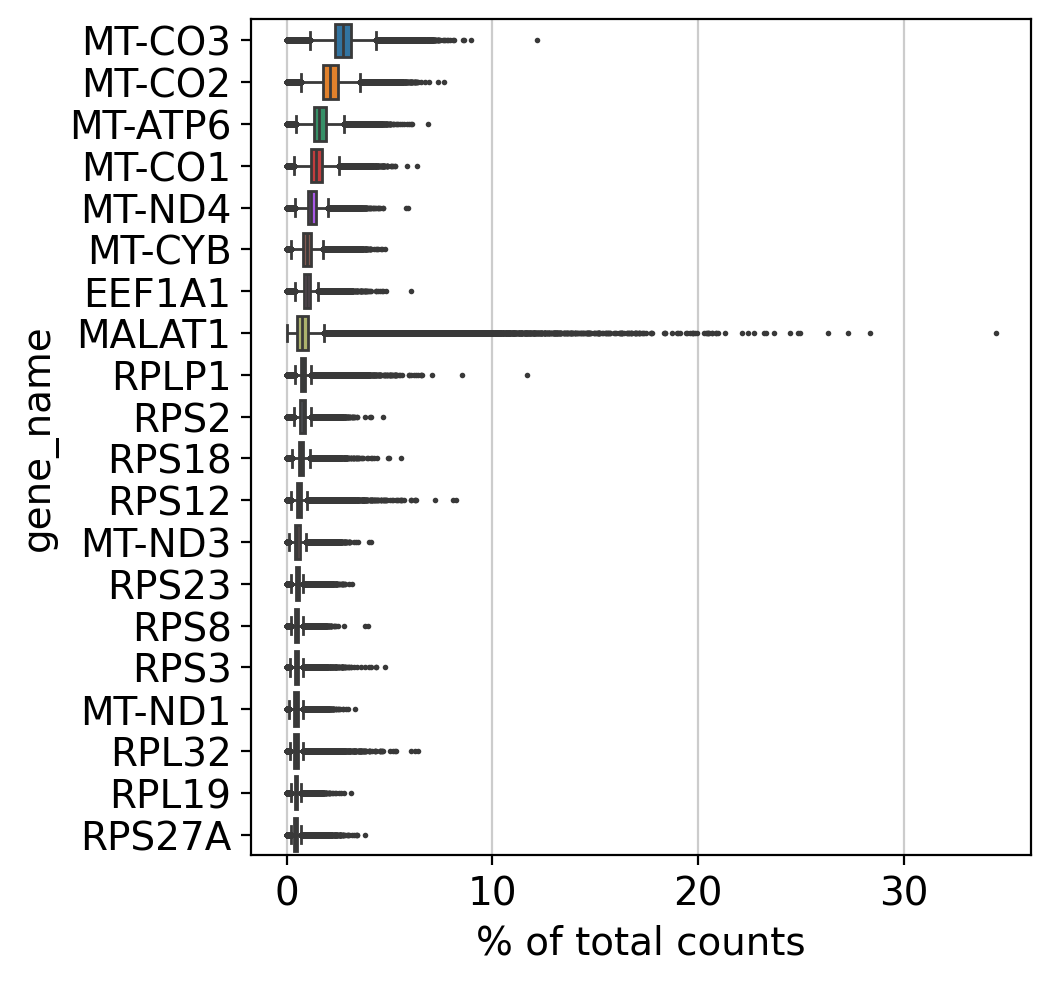

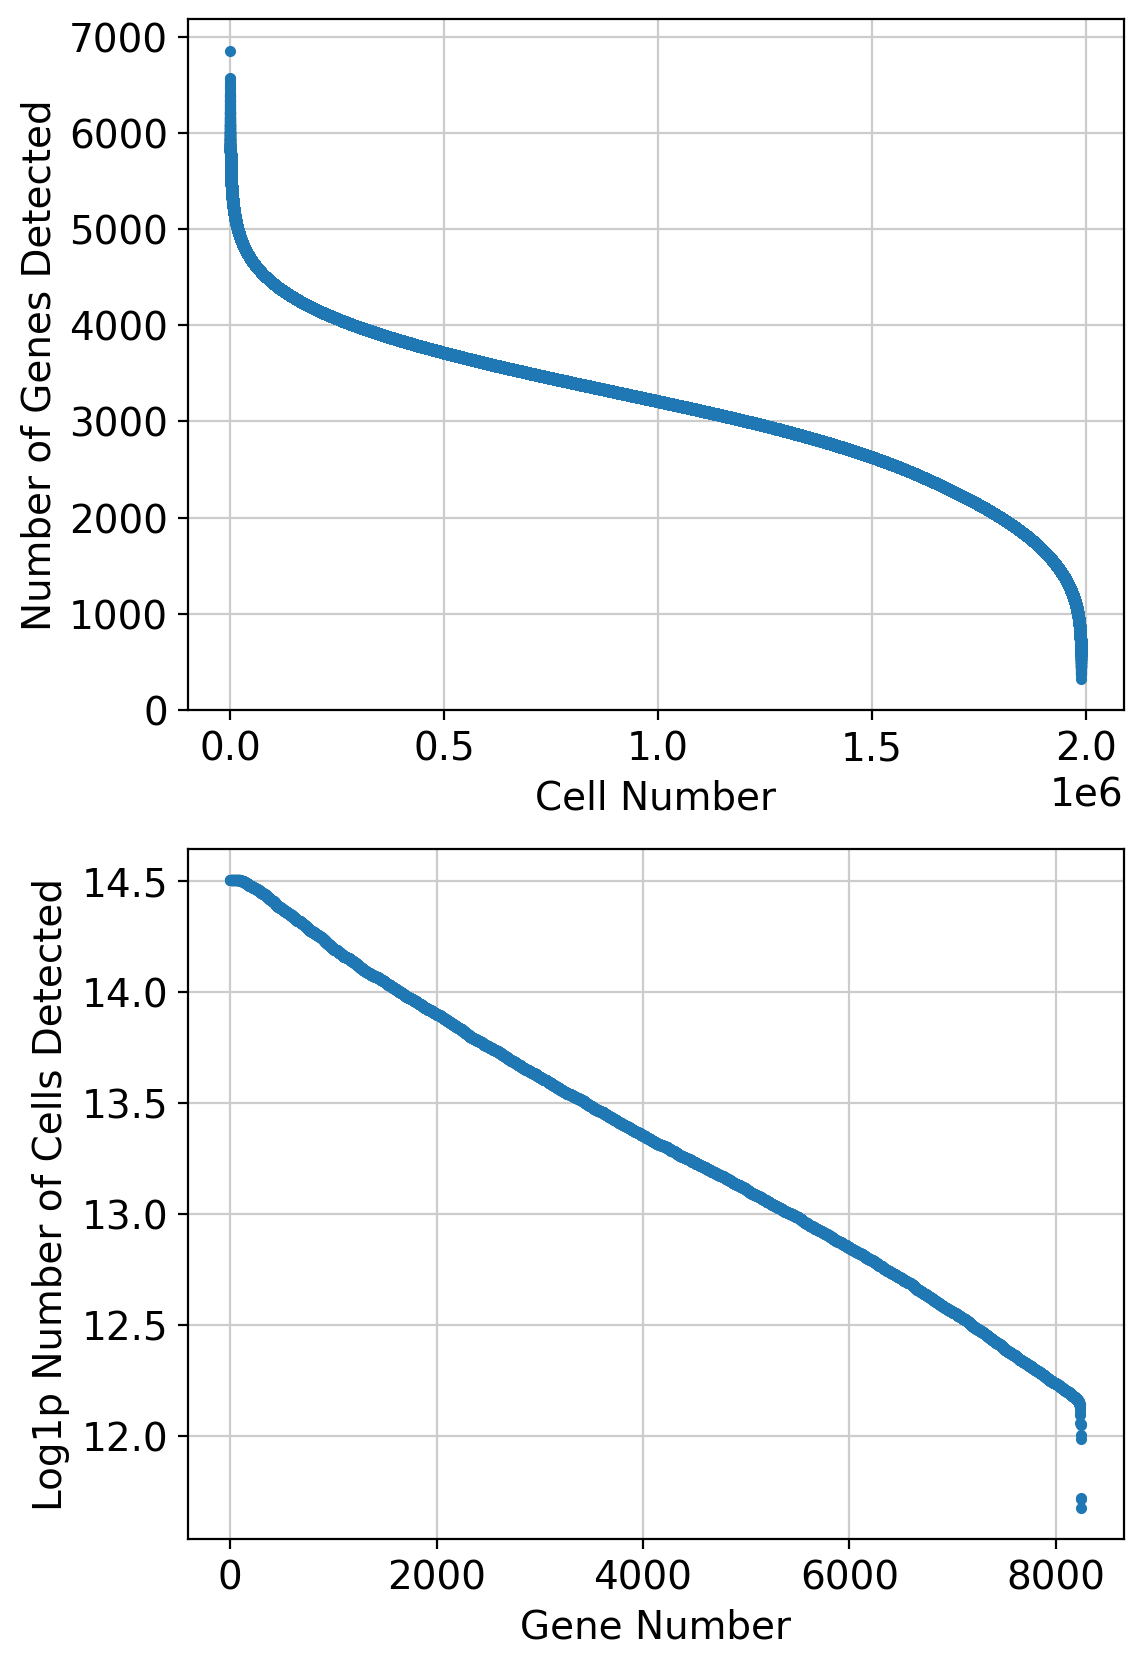

Removing 0 genes not detected in any cells.
Performing dead cell QC...


/home/ranwyl/KOLF2.1J_Perturbation_Cell_Atlas/psp/qc/quality_control.py:437: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


outlier
False    1633872
True      355706
Name: count, dtype: int64

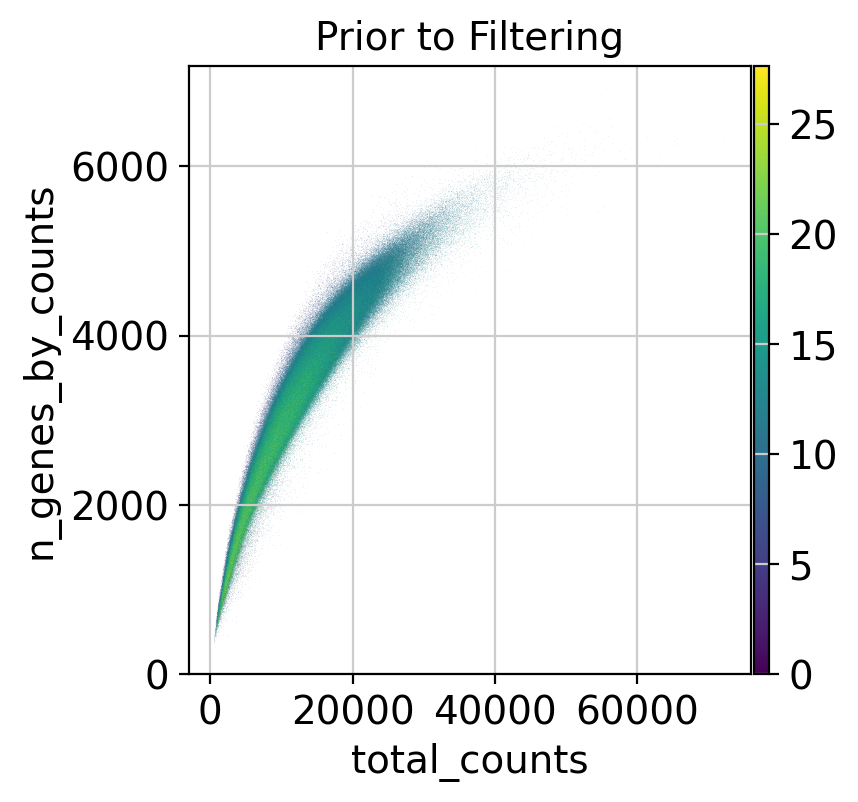

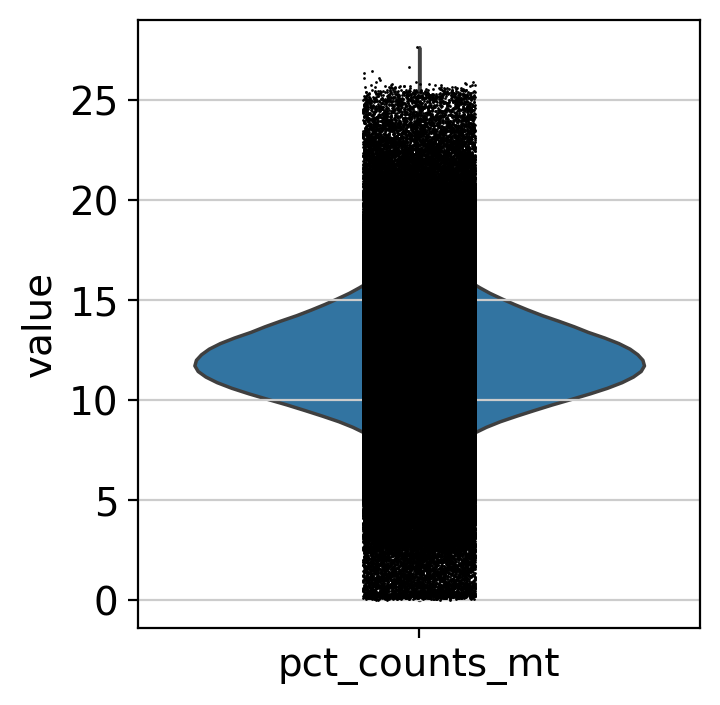

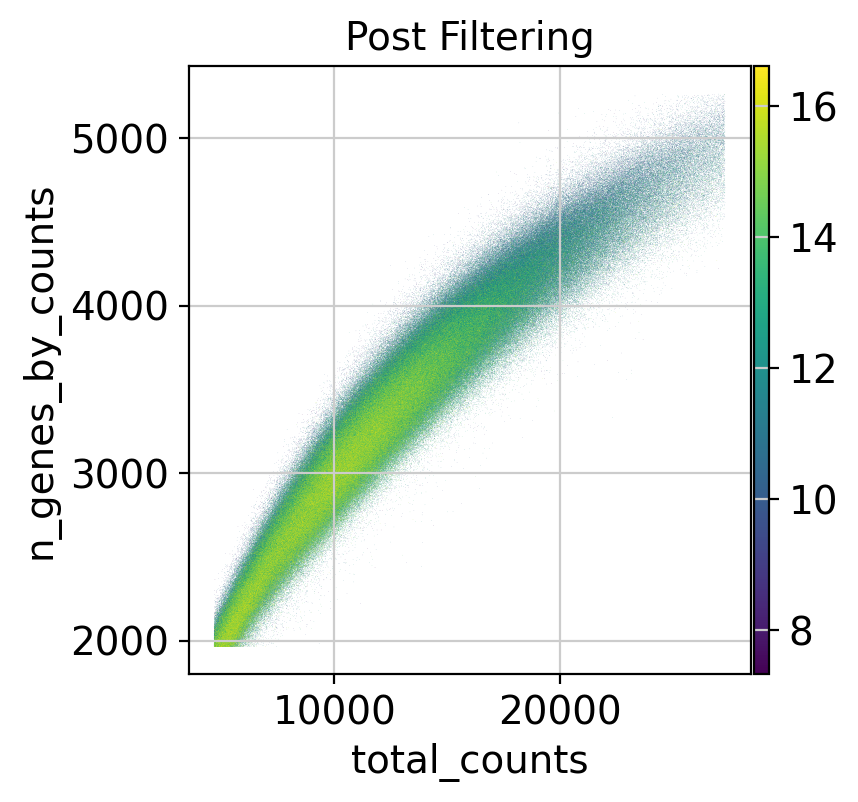

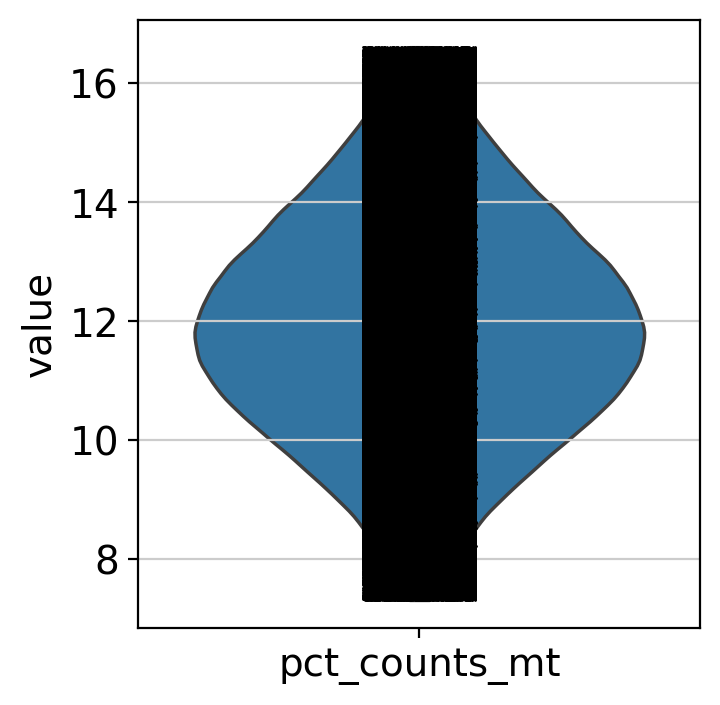

Performing doublet detection sanity check...


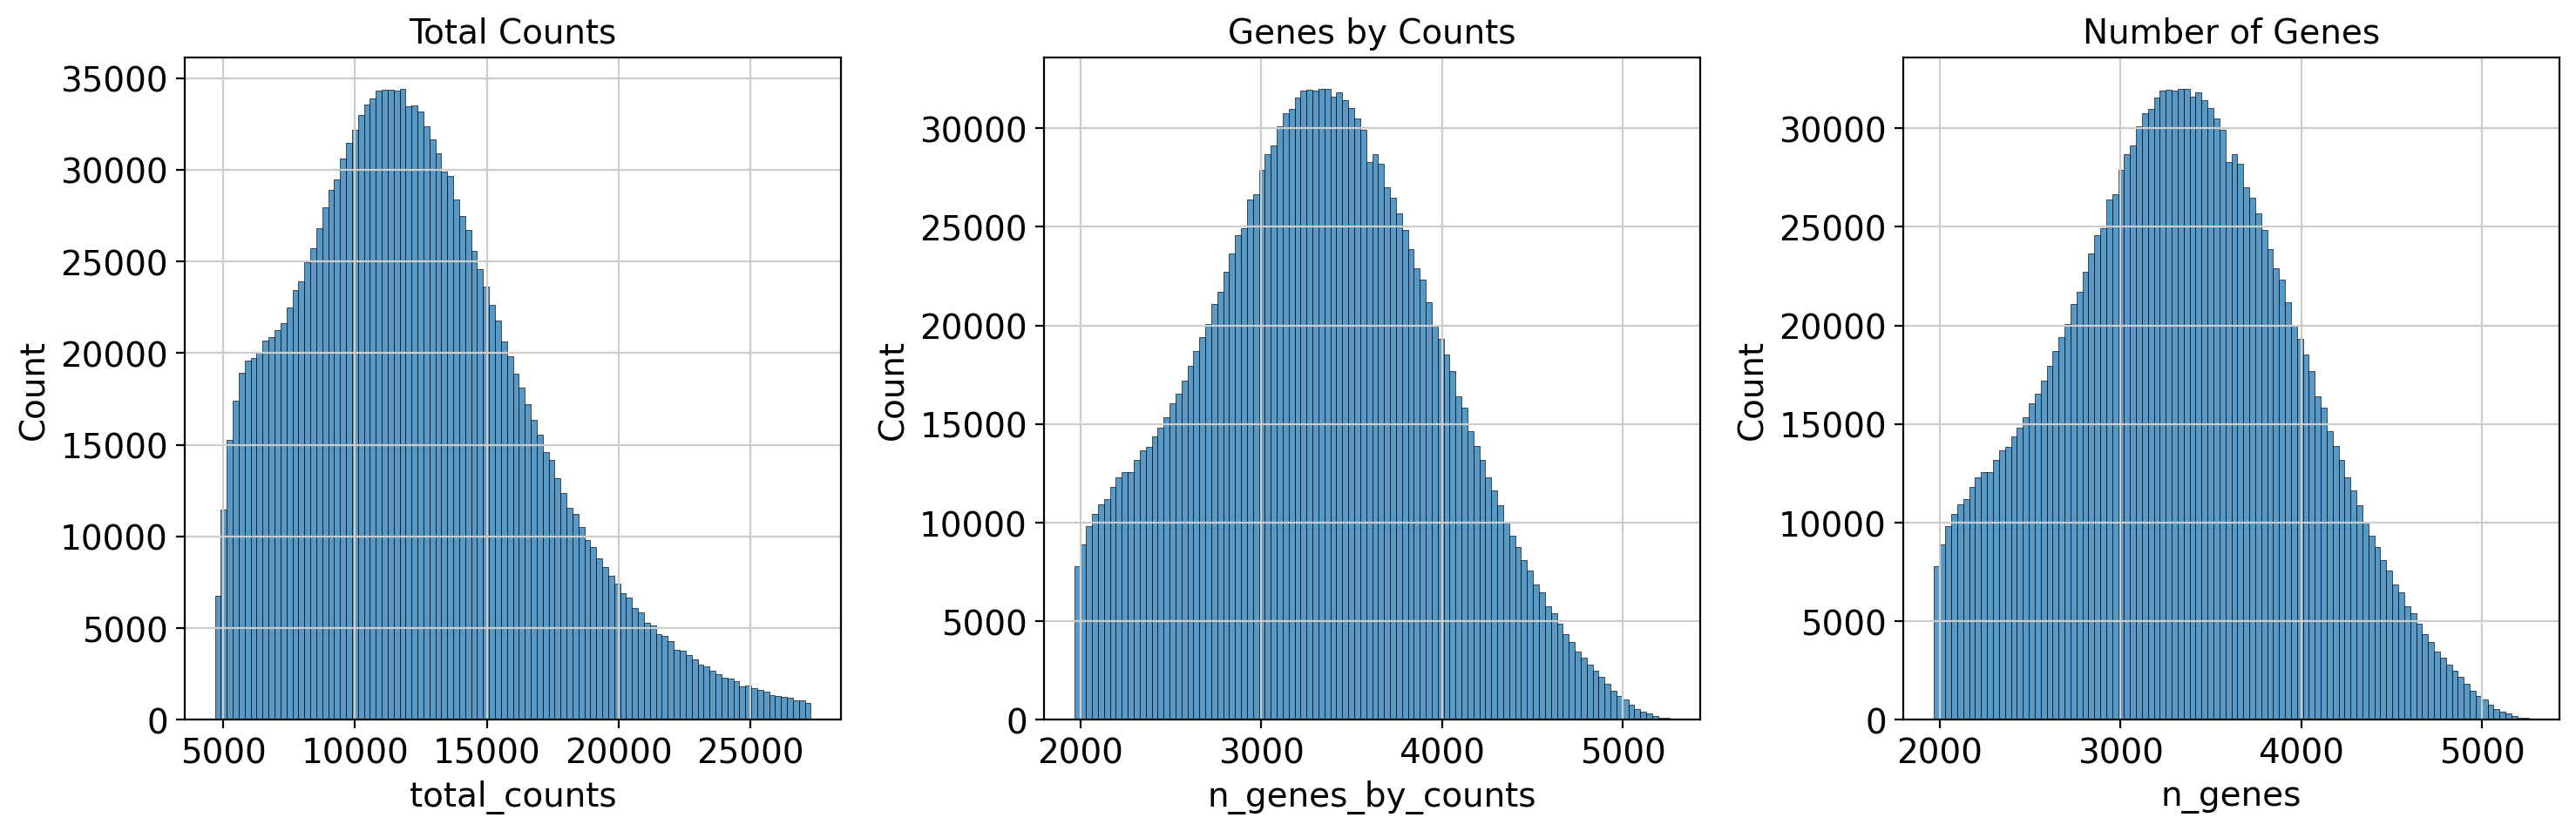

Saving final QC file to /home/ranwyl/data_tf_project/K562_QC_filtered.h5ad...


In [5]:
final_save_path = "/home/ranwyl/data_tf_project/K562_QC_filtered.h5ad"

adata_k562_qc = tf_project_basic_qc(adata_k562,
                                    count_MADs=3,
                                    final_save_path=final_save_path)

In [6]:
adata_k562_qc

View of AnnData object with n_obs × n_vars = 1633872 × 8246
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'perturbation', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'counts'

In [7]:
adata_k562_qc.obs.head(2)

,gem_group,gene,gene_id,transcript,gene_transcript,sgID_AB,mitopercent,UMI_count,z_gemgroup_UMI,core_scale_factor,...,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,outlier
cell_barcode,,,,,,,,,,,,,,,,,,,,,
AAACCCAAGAAACCAT-157,157,CTSC,ENSG00000109861,P1P2,1946_CTSC_P1P2_ENSG00000109861,CTSC_-_88070848.23-P1P2|CTSC_-_88070918.23-P1P2,0.088177,14709.0,0.470687,1.051176,...,1297.0,7.16858,8.941128,4094.0,8.317522,28.222805,57.0,4.060443,0.392941,False
AAACCCAAGAAACCAT-207,207,CWC25,ENSG00000273559,P1P2,1973_CWC25_P1P2_ENSG00000273559,CWC25_+_36981555.23-P1P2|CWC25_+_36981567.23-P1P2,0.114342,16162.0,0.824790,1.074744,...,1848.0,7.52240,11.635081,4033.0,8.302514,25.391928,28.0,3.367296,0.176289,False


In [8]:
adata_k562_qc.var.head(2)

,gene_id,chr,start,end,class,strand,length,in_matrix,mean,std,...,n_cells,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
gene_name,,,,,,,,,,,,,,,,,,,,,
LINC01409,ENSG00000237491,chr1,778747,810065,gene_version10,+,31318,True,0.116626,0.349971,...,214242,False,False,False,214242,0.116626,0.110311,89.231787,232036.0,12.354652
LINC01128,ENSG00000228794,chr1,825138,868202,gene_version9,+,43064,True,0.182850,0.437274,...,325879,False,False,False,325879,0.182850,0.167927,83.620697,363795.0,12.804349


Restart kernel

Sanity check: plot doublet detection histogram with informative title + x/y labels

In [ ]:
def plot_doublet_detection_histogram(adata: ad.AnnData,
                                     title: str = "Genes Expressed Per Cell",
                                     xlabel: str = "n_genes",
                                     ylabel: str = "n_cells",
                                     figsize: tuple[int,int] = (5,5),
                                     n_bins: int = 100,
                                     ):
    plt.figure(figsize=figsize)
    sns.histplot(adata.obs["n_genes"], bins=n_bins)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

In [ ]:
filepath = "/home/ranwyl/data_tf_project/K562_QC_filtered.h5ad"
adata_k562 = psp.utils.read_anndata(filepath)
adata_k562

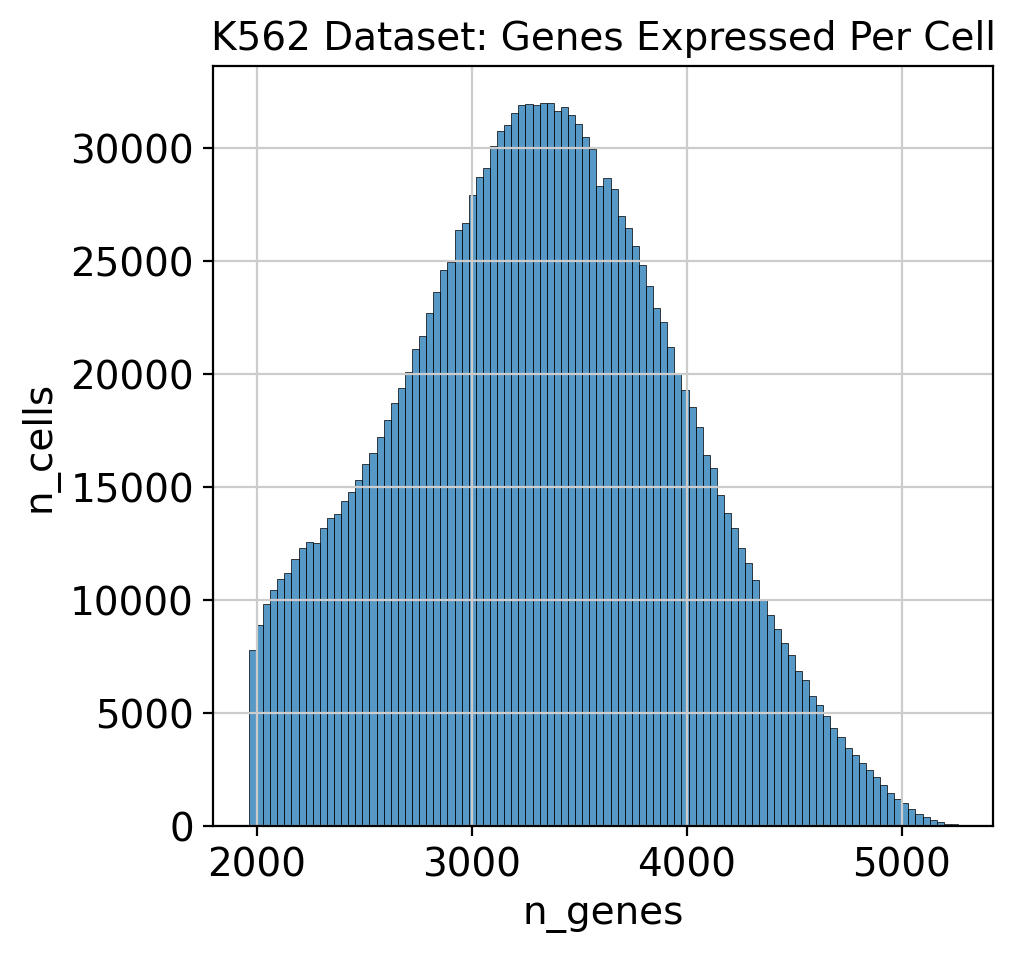

In [7]:
_ = plot_doublet_detection_histogram(adata_k562, title="K562 Dataset: Genes Expressed Per Cell")

# Filter perturbations to TF KDs only

In [3]:
filepath = "/home/ranwyl/data_tf_project/K562_QC_filtered.h5ad"
adata_k562 = psp.utils.read_anndata(filepath)
adata_k562

AnnData object with n_obs × n_vars = 1633872 × 8246
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'perturbation', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'counts'

In [4]:
k562_gene_kds = set(adata_k562[adata_k562.obs.gene != "non-targeting"].obs.gene.unique())
print(f"K562 dataset has {len(k562_gene_kds)} unique gene KDs")

K562 dataset has 9866 unique gene KDs


How many perturbations are known human TFs from Lambert et al. (2018)

In [6]:
# List of 1639 TFs from Lambert et al (2018)
tf_filepath = "/home/ranwyl/data_tf_project/input_files/Lambert_2018_TFs.csv"
tf_csv = pd.read_csv(tf_filepath)
lambert_tfs = set(tf_csv[tf_csv["Is TF?"] == "Yes"].iloc[:,1].tolist())
print(f"{len(lambert_tfs)} human TFs in Lambert et al. (2018)")

1639 human TFs in Lambert et al. (2018)


In [7]:
k562_tf_kds = k562_gene_kds & lambert_tfs
print(f"K562 dataset has {len(k562_tf_kds)} TF KDs")

K562 dataset has 1595 TF KDs


In [8]:
adata_k562_tf_kd_ntc = adata_k562[(adata_k562.obs.gene == "non-targeting") | 
                                  (adata_k562.obs.gene.isin(k562_tf_kds))].copy()
adata_k562_tf_kd_ntc

AnnData object with n_obs × n_vars = 322297 × 8246
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'perturbation', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'counts'

Check that all genes are expressed in at least 100 cells, consistent with QC on hiPSC dataset.

In [12]:
adata_k562_tf_kd_ntc.var.head()

,gene_id,chr,start,end,class,strand,length,in_matrix,mean,std,...,n_cells,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
gene_name,,,,,,,,,,,,,,,,,,,,,
LINC01409,ENSG00000237491,chr1,778747,810065,gene_version10,+,31318,True,0.116626,0.349971,...,214242,False,False,False,214242,0.116626,0.110311,89.231787,232036.0,12.354652
LINC01128,ENSG00000228794,chr1,825138,868202,gene_version9,+,43064,True,0.182850,0.437274,...,325879,False,False,False,325879,0.182850,0.167927,83.620697,363795.0,12.804349
NOC2L,ENSG00000188976,chr1,944203,959309,gene_version11,-,15106,True,1.415674,1.397208,...,1391744,False,False,False,1391744,1.415674,0.881978,30.048282,2816593.0,14.851039
KLHL17,ENSG00000187961,chr1,960584,965719,gene_version14,+,5135,True,0.105599,0.330678,...,196093,False,False,False,196093,0.105599,0.100388,90.143990,210098.0,12.255334
HES4,ENSG00000188290,chr1,998962,1000172,gene_version10,-,1210,True,0.242700,0.550596,...,391564,False,False,False,391564,0.242700,0.217286,80.319244,482870.0,13.087504


In [ ]:
adata_k562_tf_kd_ntc[:, adata_k562_tf_kd_ntc.var.n_cells < 100].var

,gene_id,chr,start,end,class,strand,length,in_matrix,mean,std,...,n_cells,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
gene_name,,,,,,,,,,,,,,,,,,,,,


In [9]:
filepath = "/home/ranwyl/data_tf_project/K562_QC_filtered_TF_KD_NTC.h5ad"
adata_k562_tf_kd_ntc.write(filepath)

Restart kernel

# Scrubbing NTC Cells

In [3]:
filepath = "/home/ranwyl/data_tf_project/K562_QC_filtered_TF_KD_NTC.h5ad"
adata_k562 = psp.utils.read_anndata(filepath)
adata_k562

AnnData object with n_obs × n_vars = 322297 × 8246
    obs: 'gem_group', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'sgID_AB', 'mitopercent', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'celltype', 'perturbation_type', 'n_genes', 'perturbed', 'perturbation', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier'
    var: 'gene_id', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'counts'

In [4]:
print(f"{adata_k562[adata_k562.obs.gene != 'non-targeting'].shape[0]} perturbed cells, "
      f"{adata_k562[adata_k562.obs.gene == 'non-targeting'].shape[0]} NTC cells")

259268 perturbed cells, 63029 NTC cells
